In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Carica tutti e tre gli universi
returns_eu = pd.read_csv(r'C:\Users\ffran\monte-carlo-sim\data\raw\returns_europe.csv',
                          index_col=0, parse_dates=True)


print(f"Asset disponibili: {returns_eu.shape[1]}")
print(f"Periodo: {returns_eu.index[0].date()} — {returns_eu.index[-1].date()}")
print(f"Osservazioni: {len(returns_eu)}")
print(f"\nTicker:\n{list(returns_eu.columns)}")

Asset disponibili: 68
Periodo: 2015-01-06 — 2025-12-31
Osservazioni: 2824

Ticker:
['ABBN.SW', 'ADS.DE', 'AIR.PA', 'ALV.DE', 'ASML.AS', 'AZN.L', 'BAS.DE', 'BAYN.DE', 'BBVA.MC', 'BMW.DE', 'BNP.PA', 'BP.L', 'BT-A.L', 'CAP.PA', 'CS.PA', 'DBK.DE', 'DG.PA', 'DGE.L', 'DSY.PA', 'DTE.DE', 'EL.PA', 'ENEL.MI', 'ENI.MI', 'ERIC-B.ST', 'G.MI', 'GIVN.SW', 'GSK.L', 'HEIA.AS', 'HEN3.DE', 'HSBA.L', 'IBE.MC', 'INGA.AS', 'ISP.MI', 'ITX.MC', 'KER.PA', 'LONN.SW', 'LSEG.L', 'MBG.DE', 'MC.PA', 'MUV2.DE', 'NDA-SE.ST', 'NESN.SW', 'NN.AS', 'NOKIA.HE', 'NOVN.SW', 'NOVO-B.CO', 'OR.PA', 'ORA.PA', 'PHIA.AS', 'REP.MC', 'RI.PA', 'RIO.L', 'ROG.SW', 'RWE.DE', 'SAN.MC', 'SAN.PA', 'SAP.DE', 'SGO.PA', 'SHEL.L', 'SIE.DE', 'SREN.SW', 'UBSG.SW', 'UCG.MI', 'ULVR.L', 'VIE.PA', 'VOLV-B.ST', 'VOW3.DE', 'ZURN.SW']


Top 10 rendimento annualizzato:
ASML.AS      27.53%
AIR.PA       21.26%
UCG.MI       20.54%
MC.PA        20.19%
VOLV-B.ST    20.00%
ISP.MI       19.83%
BBVA.MC      19.42%
LONN.SW      19.32%
MUV2.DE      18.02%
INGA.AS      18.00%
dtype: str

Top 10 volatilità annualizzata:
UCG.MI      40.67%
DBK.DE      38.61%
AIR.PA      34.28%
SAN.MC      33.69%
NOKIA.HE    33.67%
VOW3.DE     33.62%
ASML.AS     33.26%
BBVA.MC     33.21%
KER.PA      32.15%
INGA.AS     32.15%
dtype: str


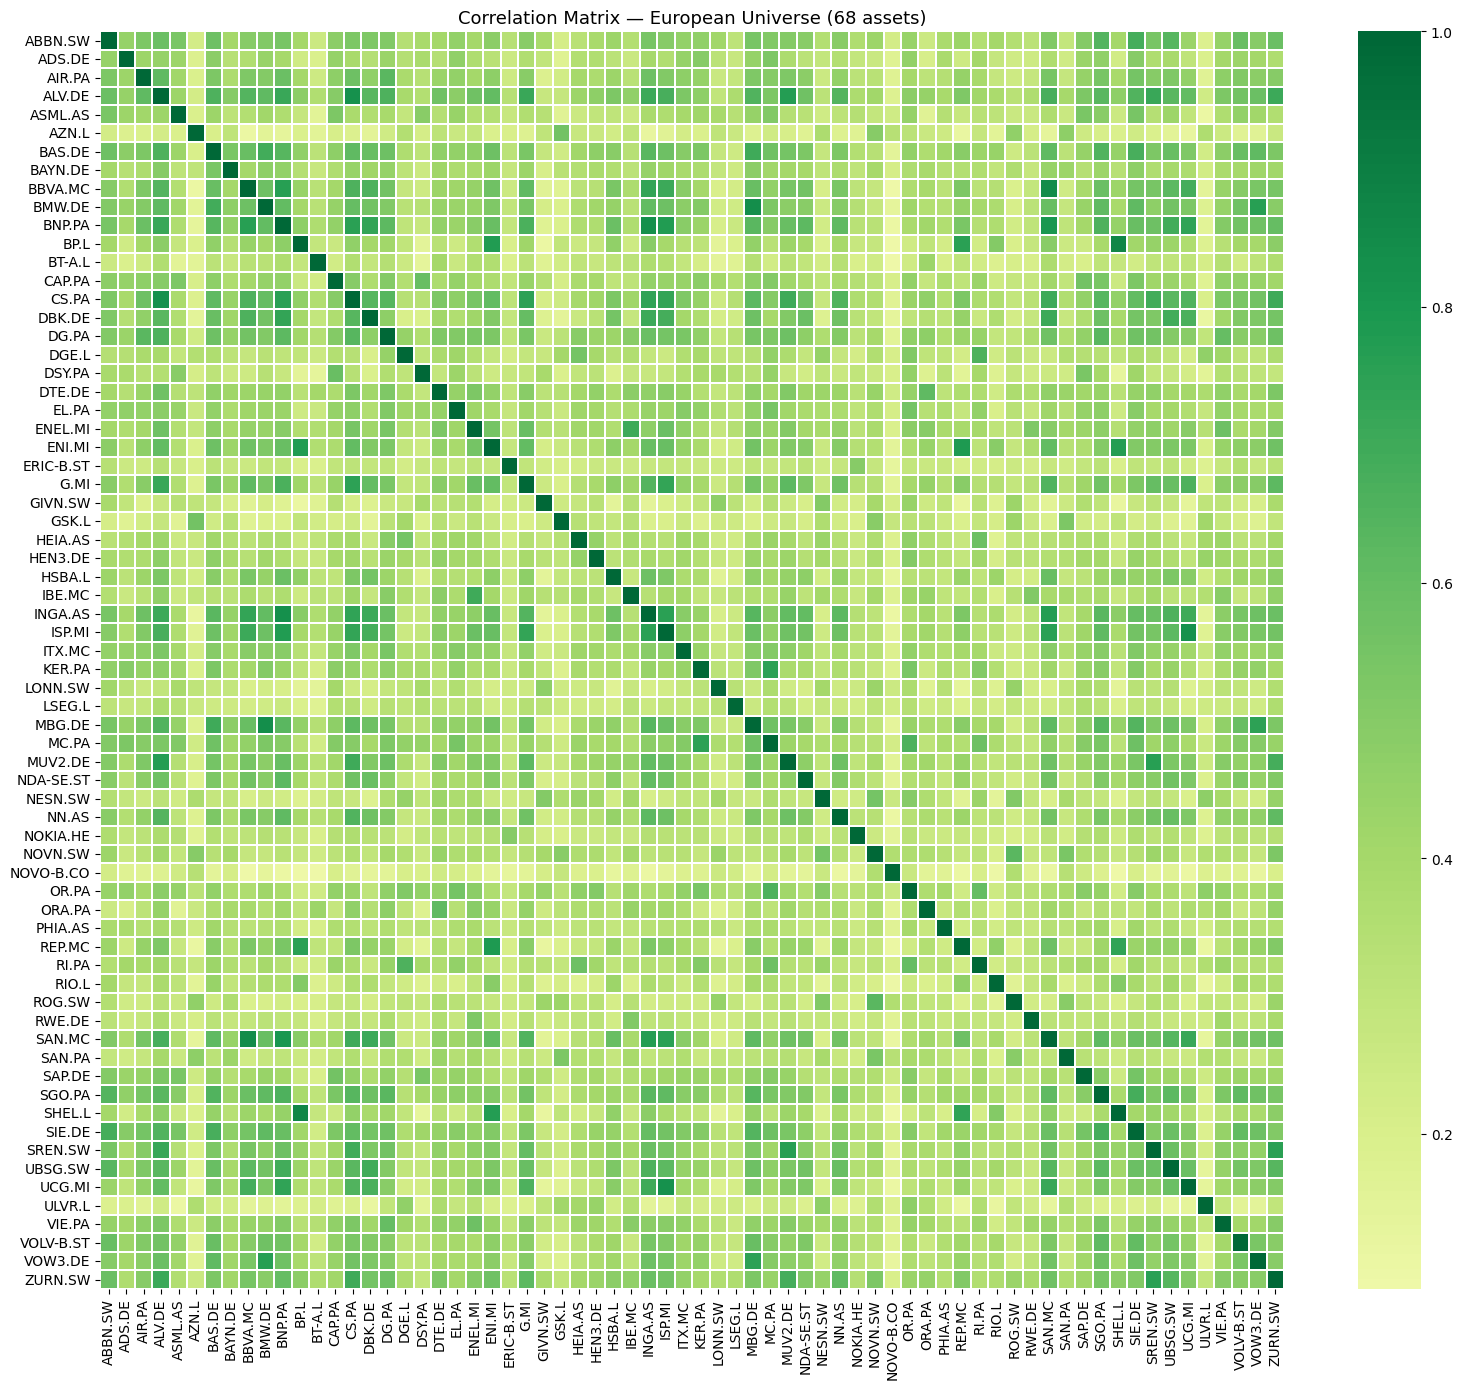

In [2]:
# Cella 1 — Statistiche descrittive universo europeo
os.makedirs('../results', exist_ok=True)

# Parametri annualizzati
mu_eu = returns_eu.mean() * 252
sigma_eu = returns_eu.std() * np.sqrt(252)
corr_eu = returns_eu.corr()

# Top 10 per rendimento
print("Top 10 rendimento annualizzato:")
print(mu_eu.sort_values(ascending=False).head(10).apply(lambda x: f"{x:.2%}"))

print("\nTop 10 volatilità annualizzata:")
print(sigma_eu.sort_values(ascending=False).head(10).apply(lambda x: f"{x:.2%}"))

# Heatmap correlazioni
fig, ax = plt.subplots(figsize=(16, 14))
sns.heatmap(corr_eu, cmap='RdYlGn', center=0, annot=False,
            linewidths=0.3, ax=ax)
ax.set_title('Correlation Matrix — European Universe (68 assets)', fontsize=13)
plt.tight_layout()
plt.savefig('../results/eu_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

Max Sharpe Portfolio:
  Return:     14.44%
  Volatility: 16.43%
  Sharpe:     0.635

Min Volatility Portfolio:
  Return:     10.27%
  Volatility: 14.93%
  Sharpe:     0.420


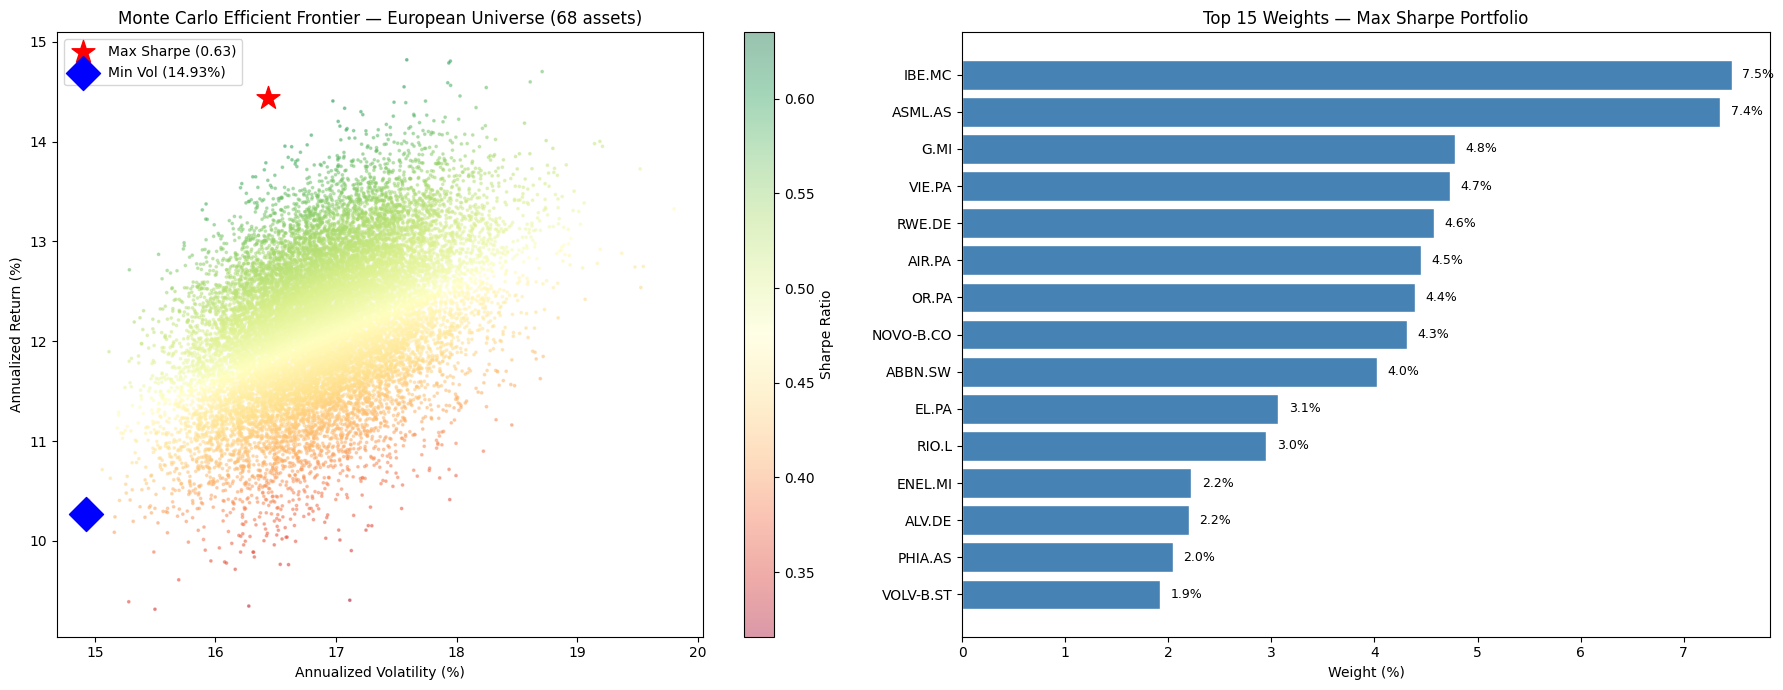

In [3]:
# Cella 2 — Monte Carlo Efficient Frontier Europa
n_portfolios = 20000
n_assets = returns_eu.shape[1]

mu_vec = returns_eu.mean().values * 252
cov_matrix = returns_eu.cov().values * 252
rf = 0.04

np.random.seed(42)
L = np.linalg.cholesky(cov_matrix)

port_returns = np.zeros(n_portfolios)
port_vols = np.zeros(n_portfolios)
port_sharpes = np.zeros(n_portfolios)
port_weights = np.zeros((n_portfolios, n_assets))

for i in range(n_portfolios):
    w = np.random.dirichlet(np.ones(n_assets))
    p_ret = w @ mu_vec
    p_vol = np.sqrt(w @ cov_matrix @ w)
    port_returns[i] = p_ret
    port_vols[i] = p_vol
    port_sharpes[i] = (p_ret - rf) / p_vol
    port_weights[i] = w

# Portafoglio ottimale
best_idx = port_sharpes.argmax()
worst_idx = port_sharpes.argmin()
min_vol_idx = port_vols.argmin()

print(f"Max Sharpe Portfolio:")
print(f"  Return:     {port_returns[best_idx]:.2%}")
print(f"  Volatility: {port_vols[best_idx]:.2%}")
print(f"  Sharpe:     {port_sharpes[best_idx]:.3f}")

print(f"\nMin Volatility Portfolio:")
print(f"  Return:     {port_returns[min_vol_idx]:.2%}")
print(f"  Volatility: {port_vols[min_vol_idx]:.2%}")
print(f"  Sharpe:     {port_sharpes[min_vol_idx]:.3f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Efficient frontier
sc = axes[0].scatter(port_vols * 100, port_returns * 100,
                     c=port_sharpes, cmap='RdYlGn',
                     alpha=0.4, s=3)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')

axes[0].scatter(port_vols[best_idx] * 100, port_returns[best_idx] * 100,
                color='red', s=300, zorder=5, marker='*',
                label=f'Max Sharpe ({port_sharpes[best_idx]:.2f})')
axes[0].scatter(port_vols[min_vol_idx] * 100, port_returns[min_vol_idx] * 100,
                color='blue', s=300, zorder=5, marker='D',
                label=f'Min Vol ({port_vols[min_vol_idx]:.2%})')

axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Monte Carlo Efficient Frontier — European Universe (68 assets)', fontsize=12)
axes[0].legend()

# Top 15 pesi portafoglio Max Sharpe
weights_series = pd.Series(port_weights[best_idx],
                           index=returns_eu.columns).sort_values(ascending=False)
top15 = weights_series.head(15)

axes[1].barh(top15.index[::-1], top15.values[::-1] * 100, color='steelblue', edgecolor='white')
axes[1].set_xlabel('Weight (%)')
axes[1].set_title('Top 15 Weights — Max Sharpe Portfolio', fontsize=12)
for i, (idx, val) in enumerate(zip(top15.index[::-1], top15.values[::-1])):
    axes[1].text(val * 100 + 0.1, i, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/eu_efficient_frontier.png', dpi=150, bbox_inches='tight')
plt.show()

In [4]:
# Cella 3 — Ottimizzazione vera con scipy
from scipy.optimize import minimize

n = len(mu_vec)

def neg_sharpe(w):
    ret = w @ mu_vec
    vol = np.sqrt(w @ cov_matrix @ w)
    return -(ret - rf) / vol

def portfolio_vol(w):
    return np.sqrt(w @ cov_matrix @ w)

constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
bounds = [(0, 1)] * n
w0 = np.ones(n) / n

# Max Sharpe
res_sharpe = minimize(neg_sharpe, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints)

# Min Volatility
res_minvol = minimize(portfolio_vol, w0, method='SLSQP',
                      bounds=bounds, constraints=constraints)

w_sharpe = res_sharpe.x
w_minvol = res_minvol.x

ret_sharpe = w_sharpe @ mu_vec
vol_sharpe = np.sqrt(w_sharpe @ cov_matrix @ w_sharpe)
sharpe_opt = (ret_sharpe - rf) / vol_sharpe

ret_minvol = w_minvol @ mu_vec
vol_minvol = np.sqrt(w_minvol @ cov_matrix @ w_minvol)
sharpe_minvol = (ret_minvol - rf) / vol_minvol

print("OTTIMIZZAZIONE REALE:")
print(f"\nMax Sharpe Portfolio:")
print(f"  Return:     {ret_sharpe:.2%}")
print(f"  Volatility: {vol_sharpe:.2%}")
print(f"  Sharpe:     {sharpe_opt:.3f}")

print(f"\nMin Volatility Portfolio:")
print(f"  Return:     {ret_minvol:.2%}")
print(f"  Volatility: {vol_minvol:.2%}")
print(f"  Sharpe:     {sharpe_minvol:.3f}")

# Top 10 pesi ottimali
print("\nTop 10 pesi Max Sharpe (ottimizzato):")
w_series = pd.Series(w_sharpe, index=returns_eu.columns).sort_values(ascending=False)
print(w_series.head(10).apply(lambda x: f"{x:.2%}"))

OTTIMIZZAZIONE REALE:

Max Sharpe Portfolio:
  Return:     19.54%
  Volatility: 16.89%
  Sharpe:     0.921

Min Volatility Portfolio:
  Return:     8.26%
  Volatility: 12.59%
  Sharpe:     0.338

Top 10 pesi Max Sharpe (ottimizzato):
IBE.MC       30.70%
ASML.AS      20.77%
LONN.SW      11.07%
VOLV-B.ST     9.11%
MUV2.DE       9.03%
NN.AS         8.44%
NOVO-B.CO     5.10%
LSEG.L        3.06%
AZN.L         2.71%
VOW3.DE       0.00%
dtype: str


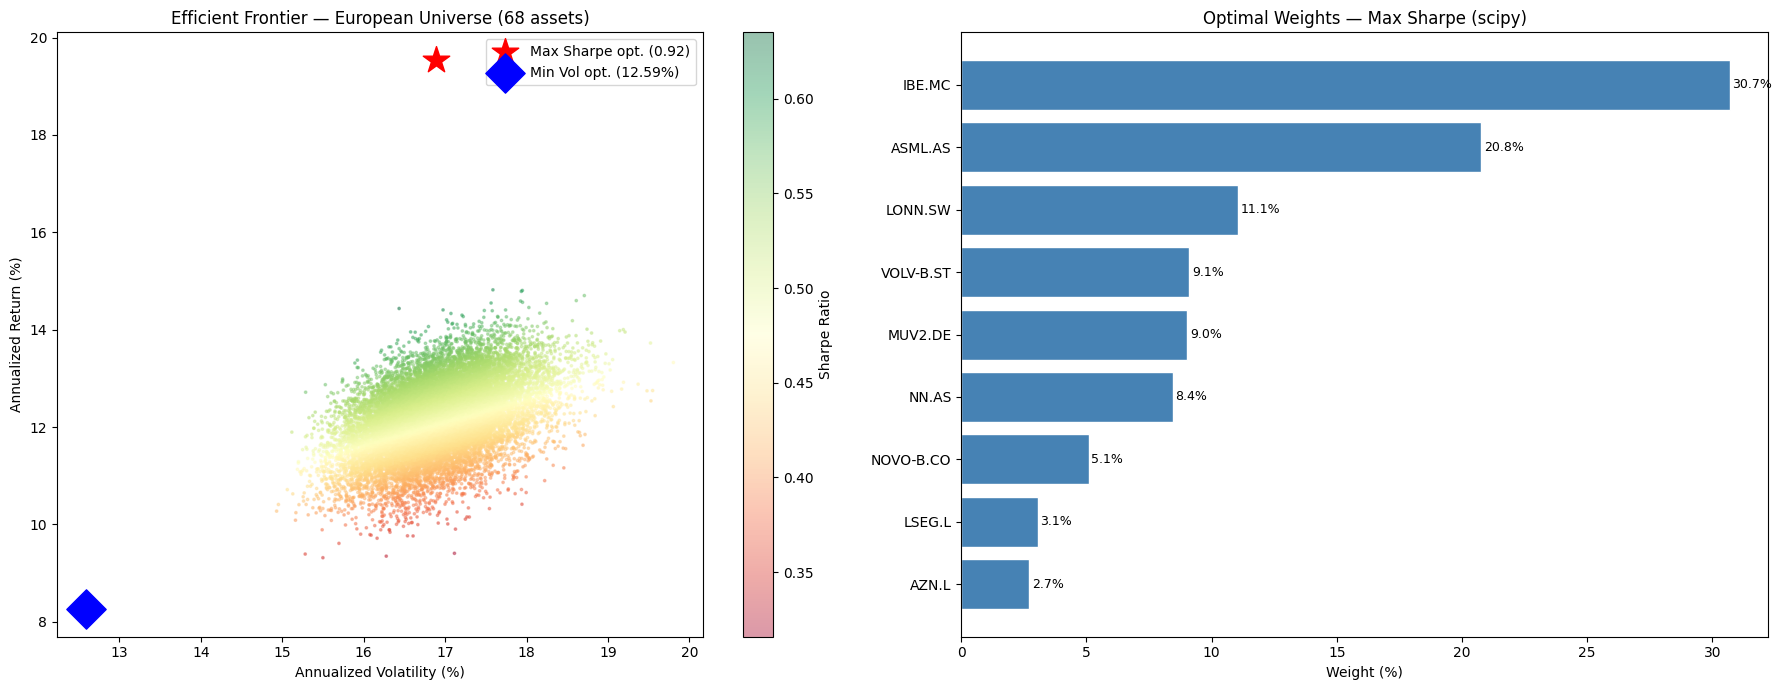

In [5]:
# Cella 4 — Aggiorna il grafico con i punti ottimali reali
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(port_vols * 100, port_returns * 100,
                     c=port_sharpes, cmap='RdYlGn',
                     alpha=0.4, s=3)
plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')

# Punti ottimizzati reali
axes[0].scatter(vol_sharpe * 100, ret_sharpe * 100,
                color='red', s=400, zorder=5, marker='*',
                label=f'Max Sharpe opt. ({sharpe_opt:.2f})')
axes[0].scatter(vol_minvol * 100, ret_minvol * 100,
                color='blue', s=400, zorder=5, marker='D',
                label=f'Min Vol opt. ({vol_minvol:.2%})')

axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Efficient Frontier — European Universe (68 assets)', fontsize=12)
axes[0].legend()

# Pesi Max Sharpe ottimizzato — solo pesi > 1%
w_plot = w_series[w_series > 0.01]
axes[1].barh(w_plot.index[::-1], w_plot.values[::-1] * 100,
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Weight (%)')
axes[1].set_title('Optimal Weights — Max Sharpe (scipy)', fontsize=12)
for i, (idx, val) in enumerate(zip(w_plot.index[::-1], w_plot.values[::-1])):
    axes[1].text(val * 100 + 0.1, i, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/eu_efficient_frontier_optimized.png', dpi=150, bbox_inches='tight')
plt.show()

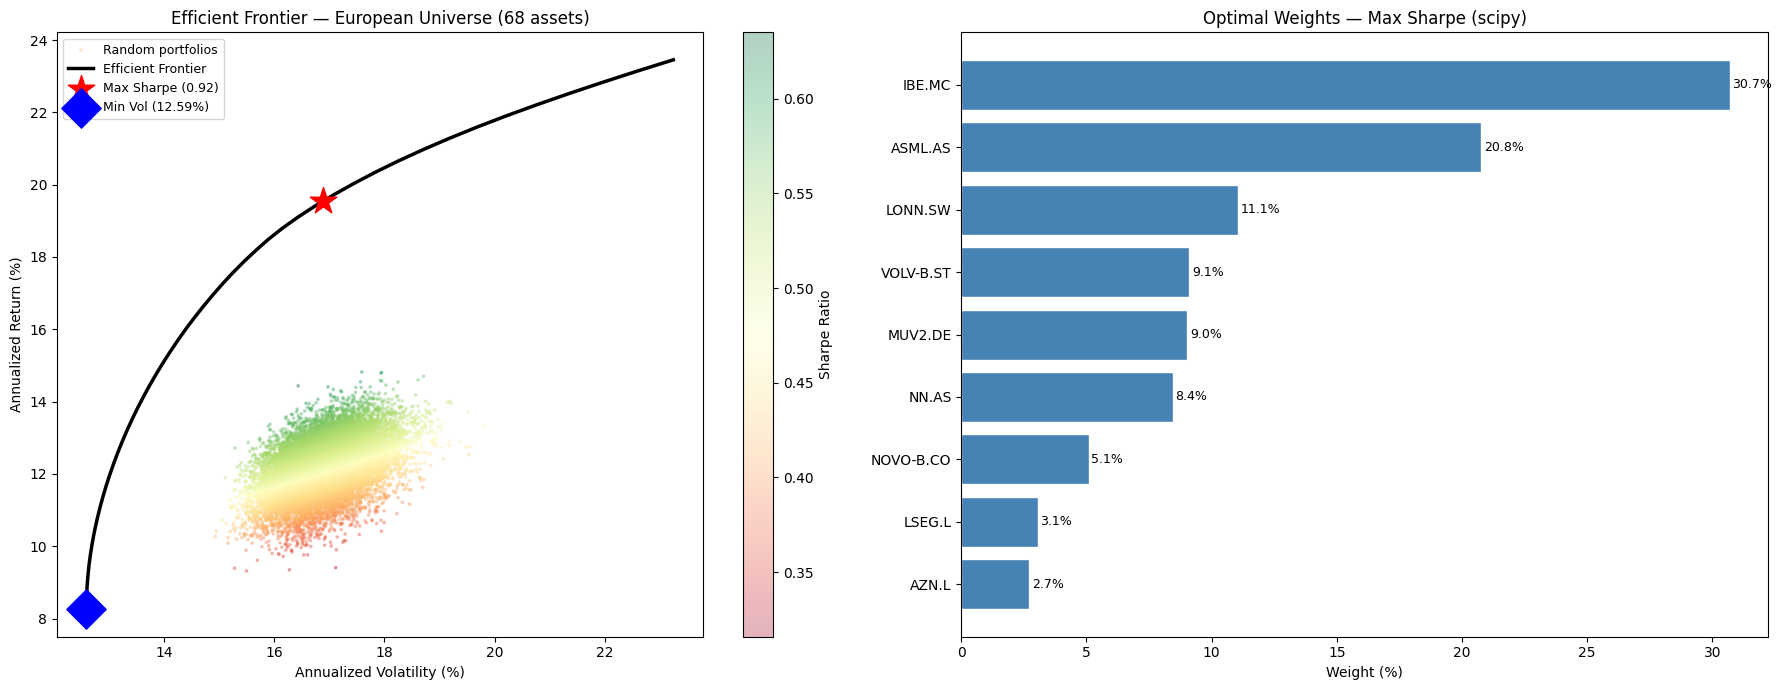

In [6]:
# Cella 5 — Frontiera efficiente come linea continua
from scipy.optimize import minimize

target_returns = np.linspace(ret_minvol, ret_sharpe * 1.2, 50)
frontier_vols = []

for target in target_returns:
    constraints = [
        {'type': 'eq', 'fun': lambda w: np.sum(w) - 1},
        {'type': 'eq', 'fun': lambda w, t=target: w @ mu_vec - t}
    ]
    res = minimize(portfolio_vol, w0, method='SLSQP',
                   bounds=bounds, constraints=constraints)
    if res.success:
        frontier_vols.append(np.sqrt(res.x @ cov_matrix @ res.x))
    else:
        frontier_vols.append(np.nan)

frontier_vols = np.array(frontier_vols)

# Grafico finale
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sc = axes[0].scatter(port_vols * 100, port_returns * 100,
                     c=port_sharpes, cmap='RdYlGn',
                     alpha=0.3, s=3, label='Random portfolios')

# Frontiera efficiente come linea
valid = ~np.isnan(frontier_vols)
axes[0].plot(frontier_vols[valid] * 100, target_returns[valid] * 100,
             color='black', linewidth=2.5, zorder=4, label='Efficient Frontier')

axes[0].scatter(vol_sharpe * 100, ret_sharpe * 100,
                color='red', s=400, zorder=5, marker='*',
                label=f'Max Sharpe ({sharpe_opt:.2f})')
axes[0].scatter(vol_minvol * 100, ret_minvol * 100,
                color='blue', s=400, zorder=5, marker='D',
                label=f'Min Vol ({vol_minvol:.2%})')

plt.colorbar(sc, ax=axes[0], label='Sharpe Ratio')
axes[0].set_xlabel('Annualized Volatility (%)')
axes[0].set_ylabel('Annualized Return (%)')
axes[0].set_title('Efficient Frontier — European Universe (68 assets)', fontsize=12)
axes[0].legend(fontsize=9)

# Pesi
w_plot = w_series[w_series > 0.01]
axes[1].barh(w_plot.index[::-1], w_plot.values[::-1] * 100,
             color='steelblue', edgecolor='white')
axes[1].set_xlabel('Weight (%)')
axes[1].set_title('Optimal Weights — Max Sharpe (scipy)', fontsize=12)
for i, (idx, val) in enumerate(zip(w_plot.index[::-1], w_plot.values[::-1])):
    axes[1].text(val * 100 + 0.1, i, f'{val:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../results/eu_efficient_frontier_final.png', dpi=150, bbox_inches='tight')
plt.show()